# Mixed-variable optimization

This page demonstrates how to minimize mixed-variable problems. SMT Optim supports float, integer and categorical variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d

# mixed-variables optimization requires the use of SMT's DesignSpace class
import smt.design_space as ds

from smt_optim import minimize

# method to fetch optimization problems
from smt_optim.benchmarks.registry import get_problem

# utility method to help with plotting 2d functions
from smt_optim.utils.plot_2d import get_plot2d_data


## Unconstrained mixed-variable optimization

The following example illustrates how to minimize the mixed-variable Branin test function. This example assumes the user is familiar with unconstrained optimization of a continuous design space. This problem has 2 continuous 'float' variables ($x_1,\; x_2$) and 2 categorical variables ($z_1,\; z_2$). It can be written mathematically as:

$$
h(x_1, x_2) =
\frac{
\left[
15 x_2
- \frac{5}{4 \pi^2} (15 x_1 - 5)^2
+ \frac{5}{\pi}(15 x_1 - 5)
- 6
\right]^2
+
10 \left(1 - \frac{1}{8\pi}\right)\cos(15 x_1 - 5)
+ 10
- 54.8104
}{51.9496}
$$

$$
f(x_1, x_2, z_1, z_2) =
\begin{cases}
    h(x_1, x_2), & \text{if } (z_1, z_2) = (0,0) \\[6pt]
    0.4\, h(x_1, x_2), & \text{if } (z_1, z_2) = (0,1) \\[6pt]
    -0.75\, h(x_1, x_2) + 3.0, & \text{if } (z_1, z_2) = (1,0) \\[6pt]
    -0.5\, h(x_1, x_2) + 1.4, & \text{if } (z_1, z_2) = (1,1)
\end{cases}
$$

The goal is to minimize the objective function over the mixed-variable design space, which can be formulated as so:

$$
\begin{aligned}
\min_{x_1, x_2, z_1, z_2} \quad & f(x_1, x_2, z_1, z_2) \\
\text{s.t.} \quad & x_1 \in [0,1], \quad x_2 \in [0,1], \quad z_1 \in \{0,1\}, \quad z_2 \in \{0,1\}.
\end{aligned}
$$

The cell below imports the test function from within SMT Optim test problems collection. The mixed-variable design space is initialized with an SMT's [DesignSpace](https://smt.readthedocs.io/en/v2.1.0/_src_docs/applications/Mixed_Hier_usage.html) class.


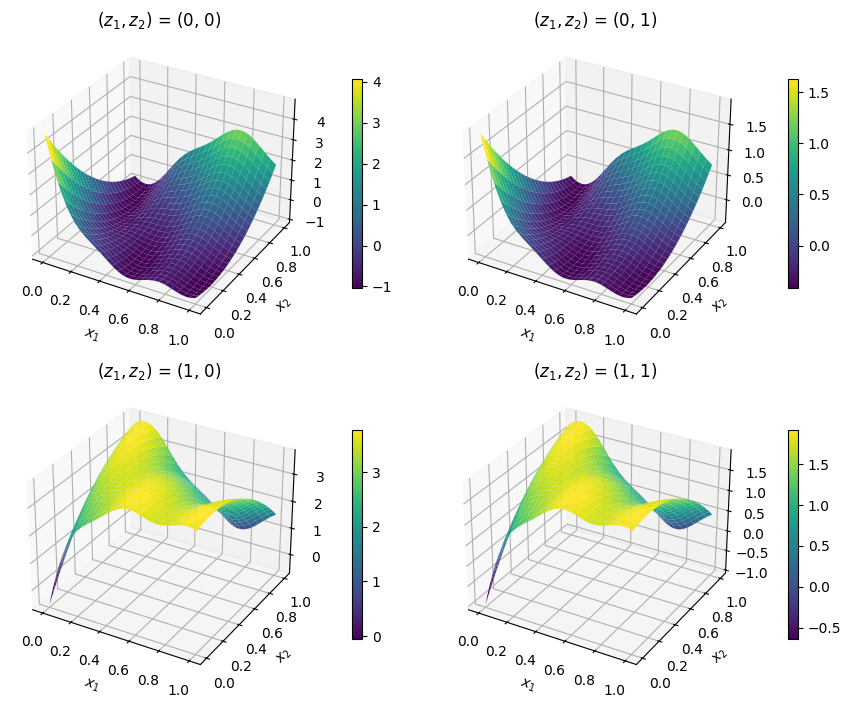

In [2]:
# fetches the mixed-variable test problem
problem = get_problem("MixVarBranin")

# defines the design space using SMT's DesignSpace class
design_space = ds.DesignSpace([
    ds.FloatVariable(lower=0, upper=1),
    ds.FloatVariable(lower=0, upper=1),
    ds.CategoricalVariable([0, 1]),
    ds.CategoricalVariable([0, 1]),
])

# ------- plots the test problem -------
bounds = np.array([
    [0, 1],
    [0, 1],
])

z_combinations = [
    (0, 0),
    (0, 1),
    (1, 0),
    (1, 1),
]

fig = plt.figure(figsize=(9, 7))

for i, (z1, z2) in enumerate(z_combinations, start=1):

    def wrapper(x):
        x0 = np.array([x[0], x[1], z1, z2])
        return problem.objective(x0)

    XX, YY, Z = get_plot2d_data(wrapper, bounds, 51)

    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(XX, YY, Z, cmap="viridis", edgecolor="none")
    ax.set_title(r"$(z_1, z_2)$ = (" + str(z1) + ", " + str(z2) + ")")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

    fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1)

plt.tight_layout(h_pad=2.5)
plt.show()


### Starting the optimization

The Bayesian optimization is started with the `minimize` method. To define a mixed-variable design space instead of a continuous one, an SMT's DesignSpace object must be given to the `design space` argument.

In [3]:
# starts the optimization
state = minimize(
    [problem.objective],            # list of callables (single callable for mono-fidelity)
    design_space,                   # SMT's Design Space object
    max_iter=10,
    driver_kwargs={"seed": 0}
)

# fetches the best sample
best_sample = state.get_best_sample()
print(best_sample)


          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1              6   -6.95818e-01      0.000e+00              1          0.368          1.613
             2              7   -6.95818e-01      0.000e+00              1          0.393          1.855
             3              8   -6.95818e-01      0.000e+00              1          0.414          1.127
             4              9   -9.02607e-01      0.000e+00              1          0.390          1.443
             5             10   -9.02607e-01      0.000e+00              1          0.428          1.357
             6             11   -9.52011e-01      0.000e+00              1          0.456          1.474
             7             12   -1.04257e+00      0.000e+00              1          0.485          1.533
             8             13   -1.04257e+00      0.000e+00              1          0.557          1.221
             9             14   -1.04257e+00      0.000

### Plotting the results

The code snippet below plots the best sample, displayed with a star, against the test problem.


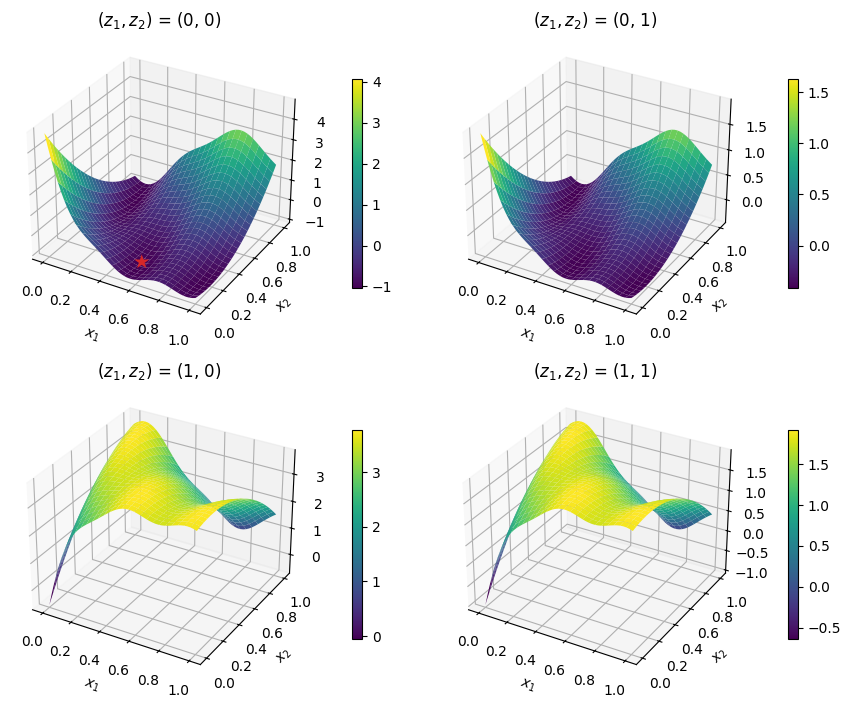

In [4]:
x_star = best_sample.x
y_star = best_sample.obj[0]
#  categorical variables
z1_star = x_star[2]
z2_star = x_star[3]

# ------- plots the best sample against the functions -------
fig = plt.figure(figsize=(9, 7))

for i, (z1, z2) in enumerate(z_combinations, start=1):

    def wrapper(x):
        x0 = np.array([x[0], x[1], z1, z2])
        return problem.objective(x0)

    XX, YY, Z = get_plot2d_data(wrapper, bounds, 51)

    ax = fig.add_subplot(2, 2, i, projection="3d")
    surf = ax.plot_surface(XX, YY, Z, cmap="viridis", edgecolor="none", zsort="min")

    ax.set_title(r"$(z_1, z_2)$ = (" + str(z1) + ", " + str(z2) + ")")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1)

    if z1 == z1_star and z2 == z2_star:

        x2, y2, _ = proj3d.proj_transform(
            x_star[0], x_star[1], y_star,
            ax.get_proj()
        )

        ax.annotate(
            "★",
            (x2, y2),
            color="C3",
            fontsize=14,
            ha="center"
        )

plt.tight_layout(h_pad=2.5)
plt.show()

## Constrained, multi-fidelity, and mixed-variable optimization

The following example illustrates how to minimize the constrained, multi-fidelity, mixed-variable Branin test function. This example assumes the user is familiar with constrained and multi-fidelity optimization.  The problem's design space has 2 continuous 'float' variables and 2 categorical variables. The mixed-variable constraint function is defined as:

$$
g(x_1, x_2, z_1, z_2) =
\begin{cases}
- x_1 x_2 + 0.4 & \text{if } (z_1, z_2) = (0,0), \\
- 1.5\,x_1 x_2 + 0.4 & \text{if } (z_1, z_2) = (0,1), \\
- 1.5\,x_1 x_2 + 0.2 & \text{if } (z_1, z_2) = (1,0), \\
- 1.2\,x_1 x_2 + 0.3 & \text{if } (z_1, z_2) = (1,1),
\end{cases}
$$

The multi-fidelity objective and constraint functions take the following form:

$$
\begin{aligned}
f_{\mathrm{HF}}(x_1, x_2, z_1, z_2) &= f(x_1, x_2, z_1, z_2), \\
f_{\mathrm{LF}}(x_1, x_2, z_1, z_2) &= f_{\mathrm{HF}}(x_1, x_2, z_1, z_2) - \cos(0.5x_1) - x_2^3, \\
g_{\mathrm{HF}}(x_1, x_2, z_1, z_2) &= g(x_1, x_2, z_1, z_2), \\
g_{\mathrm{LF}}(x_1, x_2, z_1, z_2) &= g_{\mathrm{HF}}(x_1, x_2) - 0.1 \sin(10x_1 + 5x_2),
\end{aligned}
$$

where $f(\boldsymbol x)$ is the same objective function as the previous example. The goal is to minimize the high-fidelity objective function with respect to the inequality constraint and leverage their 'cheaper' approximation to reduce the optimization cost.
$$
\begin{aligned}
\min_{\boldsymbol x \in \mathbb R^2, \; \boldsymbol z \in \mathbb Z_+^2} \quad & f_\text{HF}(x_1, x_2, z_1, z_2) \\
\text{s.t.} \quad
& 0 \leq x_i \leq 1 \quad i = 1, 2 \\
& z_i \in \{0, 1\} \quad i = 1, 2 \\
& g_\text{HF} (x_1, x_2, z_1, z_2) \leq 0.
\end{aligned}
$$

The cell below imports the test function from within SMT Optim test problems collection. The design space is initialized with an SMT's `DesignSpace` class. The figure shows the low- (in purple) and high-fidelity (in blue) test problems over their entire design space. The semi-transparent regions denote the unfeasible regions due to the inequality constraint.


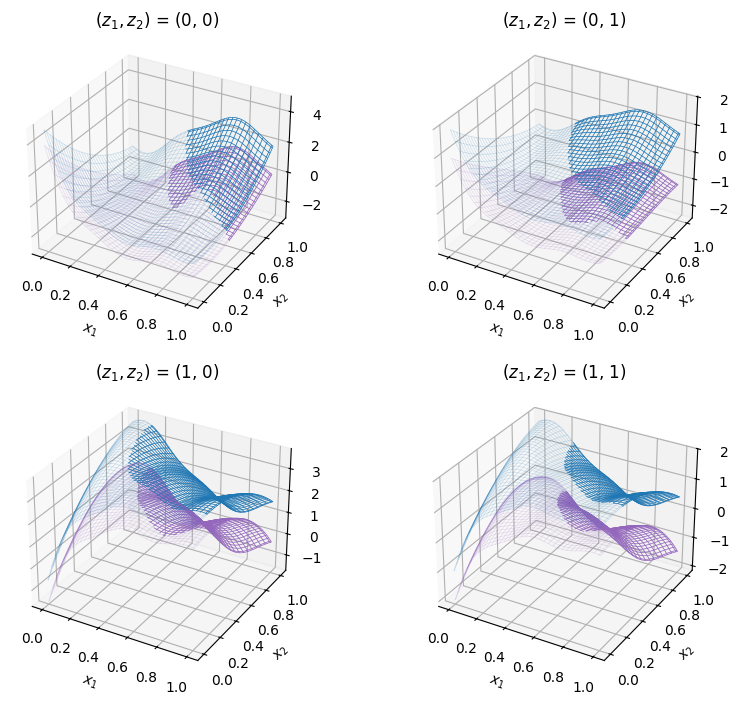

In [5]:

# fetches the mixed-variable test problem
problem = get_problem("MultiFidelityMixVarBranin")

# defines the design space using SMT's DesignSpace class
design_space = ds.DesignSpace([
    ds.FloatVariable(lower=0, upper=1),
    ds.FloatVariable(lower=0, upper=1),
    ds.CategoricalVariable([0, 1]),
    ds.CategoricalVariable([0, 1]),
])

# ------- plots the test problem -------
bounds = np.array([
    [0, 1],
    [0, 1],
])

z_combinations = [
    (0, 0),
    (0, 1),
    (1, 0),
    (1, 1),
]

colors = ["C4", "C0"]

fig = plt.figure(figsize=(9, 7))

for i, (z1, z2) in enumerate(z_combinations, start=1):

    ax = fig.add_subplot(2, 2, i, projection="3d")

    for lvl in range(problem.num_fidelity):

        def wrapper(x, func):
            x0 = np.array([x[0], x[1], z1, z2])
            return func(x0)

        XX, YY, Z = get_plot2d_data(lambda x, f=problem.objectives[lvl]: wrapper(x, func=f), bounds, 101)
        _, _, G = get_plot2d_data(lambda x, f=problem.constraints[0][lvl]: wrapper(x, func=f), bounds, 101)

        Z_feas = np.where(G > 0, np.nan, Z)

        ax.set_title(r"$(z_1, z_2)$ = (" + str(z1) + ", " + str(z2) + ")", pad=5.0)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.plot_wireframe(XX, YY, Z_feas, linewidth=0.5, edgecolor=colors[lvl])
        ax.plot_wireframe(XX, YY, Z, alpha=0.2, linewidth=0.5, edgecolor=colors[lvl])

plt.tight_layout(h_pad=2.5)
plt.show()

### Starting the optimization

The Bayesian optimization is started by calling the `minimize` method. To define a mixed-variable design space instead of a continuous one, an SMT's DesignSpace object must be given to the `design space` argument. Additionally, the objective argument expects a list of method callables; the same applies to any constraints.


In [6]:
# defines the constraint
constraint = [
    {
        "fun": problem.constraints[0],      # list of callables
        "upper": 0.,                        # g(x) <= 0
    }
]

# starts the optimization
state = minimize(
    problem.objectives,                     # list of callables
    design_space,                           # ds.DesignSpace object
    constraints=constraint,
    costs=[0.2, 1.],
    max_iter=10,
    max_budget=10,
    # arguments passed to the optimization driver
    driver_kwargs={
        "nt_init": 3,
        "seed": 42
    },
    # arguments passed to the acquisition strategy
    strategy_kwargs={
        "fidelity_crit": "pessimistic",
        "sp_method": "Cobyla",
        "sp_tol": 1e-4
    }
)

# fetches the best sample
best_sample = state.get_best_sample()
print(best_sample)


          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1          4.400    2.70574e+00      0.000e+00              1          2.841          2.537
             2          4.600    2.70574e+00      0.000e+00              1          1.602          2.157
             3          4.800    2.70574e+00      0.000e+00              1          1.660          1.996
             4          5.000    2.70574e+00      0.000e+00              1          1.579          2.423
             5          5.200    2.70574e+00      0.000e+00              1          1.252          2.725
             6          5.400    2.70574e+00      0.000e+00              1          1.644          4.044
             7          5.600    2.70574e+00      0.000e+00              1          1.657         15.491
             8          6.800   -7.36781e-01      0.000e+00              2          1.374          5.550
             9          7.000   -7.36781e-01      0.000

### Plotting the results

The code snippet below plots the best sample, displayed with a star, against the test problem.


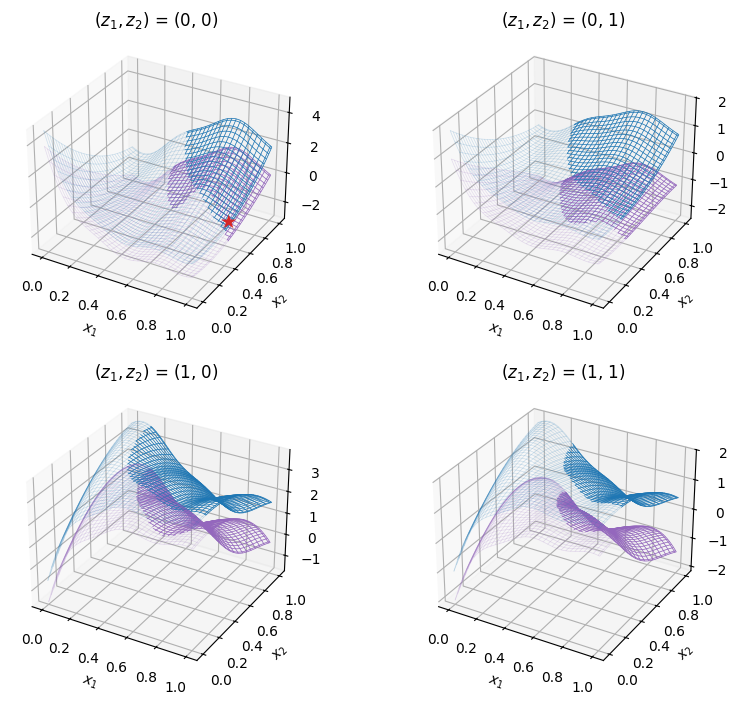

In [7]:

best_sample = state.get_best_sample()
x_star = best_sample.x
y_star = best_sample.obj[0]
#  categorical variables
z1_star = x_star[2]
z2_star = x_star[3]

# ------- plots the best sample against the functions -------
fig = plt.figure(figsize=(9, 7))

for i, (z1, z2) in enumerate(z_combinations, start=1):

    ax = fig.add_subplot(2, 2, i, projection="3d")

    for lvl in range(problem.num_fidelity):

        def wrapper(x, func):
            x0 = np.array([x[0], x[1], z1, z2])
            return func(x0)

        XX, YY, Z = get_plot2d_data(lambda x, f=problem.objectives[lvl]: wrapper(x, func=f), bounds, 101)
        _, _, G = get_plot2d_data(lambda x, f=problem.constraints[0][lvl]: wrapper(x, func=f), bounds, 101)

        Z_feas = np.where(G > 0, np.nan, Z)

        ax.set_title(r"$(z_1, z_2)$ = (" + str(z1) + ", " + str(z2) + ")")
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.plot_wireframe(XX, YY, Z_feas, linewidth=0.5, edgecolor=colors[lvl])
        ax.plot_wireframe(XX, YY, Z, alpha=0.2, linewidth=0.5, edgecolor=colors[lvl])

    if z1 == z1_star and z2 == z2_star:

        x2, y2, _ = proj3d.proj_transform(
            x_star[0], x_star[1], y_star,
            ax.get_proj()
        )

        ax.annotate(
            "★",
            (x2, y2),
            color="C3",
            fontsize=14,
            ha="center",
            zorder=20,
        )

plt.tight_layout(h_pad=2.5)
plt.show()
